# Term Deposit Marketing - Base Model Logistic Regression

### Data Load

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

In [143]:
file_path = r"../data/term-deposit-marketing-2020.csv"
df = pd.read_csv(file_path)
# df.info()
# df.describe()
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


### Prepare Features

In [144]:
# Target
y = (df["y"] == "yes").astype(int)
X = df.drop(columns=["y"])
X["is_student_or_retired"] = df["job"].isin(["student", "retired"]).astype(int)
X["low_campaign_flag"] = (df["campaign"] <= 2).astype(int)
X["balance_bin"] = pd.qcut(df["balance"], 5, labels=False)
# X.drop(columns=["duration", "job", "contact", "month", "campaign", "balance"], inplace=True)

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "str"]).columns
print(categorical_cols)
print(numeric_cols)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month'],
      dtype='str')
Index(['age', 'balance', 'day', 'duration', 'campaign',
       'is_student_or_retired', 'low_campaign_flag', 'balance_bin'],
      dtype='str')


In [145]:
X_encoded = pd.get_dummies(X, columns=categorical_cols)
print("Shape: ", X_encoded.shape)
X_encoded.head()

Shape:  (40000, 47)


,age,balance,day,duration,campaign,is_student_or_retired,low_campaign_flag,balance_bin,job_admin,job_blue-collar,...,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
0,58,2143,5,261,1,0,1,4,False,False,...,False,False,False,False,False,False,False,True,False,False
1,44,29,5,151,1,0,1,1,False,False,...,False,False,False,False,False,False,False,True,False,False
2,33,2,5,76,1,0,1,0,False,False,...,False,False,False,False,False,False,False,True,False,False
3,47,1506,5,92,1,0,1,3,False,True,...,False,False,False,False,False,False,False,True,False,False
4,33,1,5,198,1,0,1,0,False,False,...,False,False,False,False,False,False,False,True,False,False


In [146]:
# Correlation with Target
corr_with_target = X_encoded.corrwith(y).sort_values(ascending=False)
corr_with_target

duration                 0.461169
month_mar                0.128125
month_apr                0.097450
month_oct                0.093298
contact_cellular         0.085433
balance_bin              0.057330
housing_no               0.054336
marital_single           0.051721
education_tertiary       0.046763
is_student_or_retired    0.040668
job_student              0.037384
month_feb                0.036816
loan_no                  0.031029
low_campaign_flag        0.030464
balance                  0.030232
job_retired              0.024343
job_management           0.020291
marital_divorced         0.014619
job_unemployed           0.009463
job_admin                0.008083
default_no               0.006559
job_self-employed        0.005029
month_dec                0.000315
job_technician           0.000234
job_unknown             -0.000018
contact_telephone       -0.000842
day                     -0.006420
default_yes             -0.006559
job_entrepreneur        -0.007191
education_unkn

In [147]:
# drop "unknown" fields
# X_encoded.drop(["job_unknown", "education_unknown", "contact_unknown"], axis=1, inplace=True)

# drop collinear fields
X_encoded.drop(["default_no", "housing_no", "loan_no"], axis=1, inplace=True)

# drop low corr fields
# X_encoded.drop(["month_dec", "job_technician", "contact_telephone"], axis=1, inplace=True)

# Preprocessing
# X_encoded.drop(["education_unknown", "default_no", "housing_no", "loan_no"], axis=1, inplace=True)
# X_encoded.head()

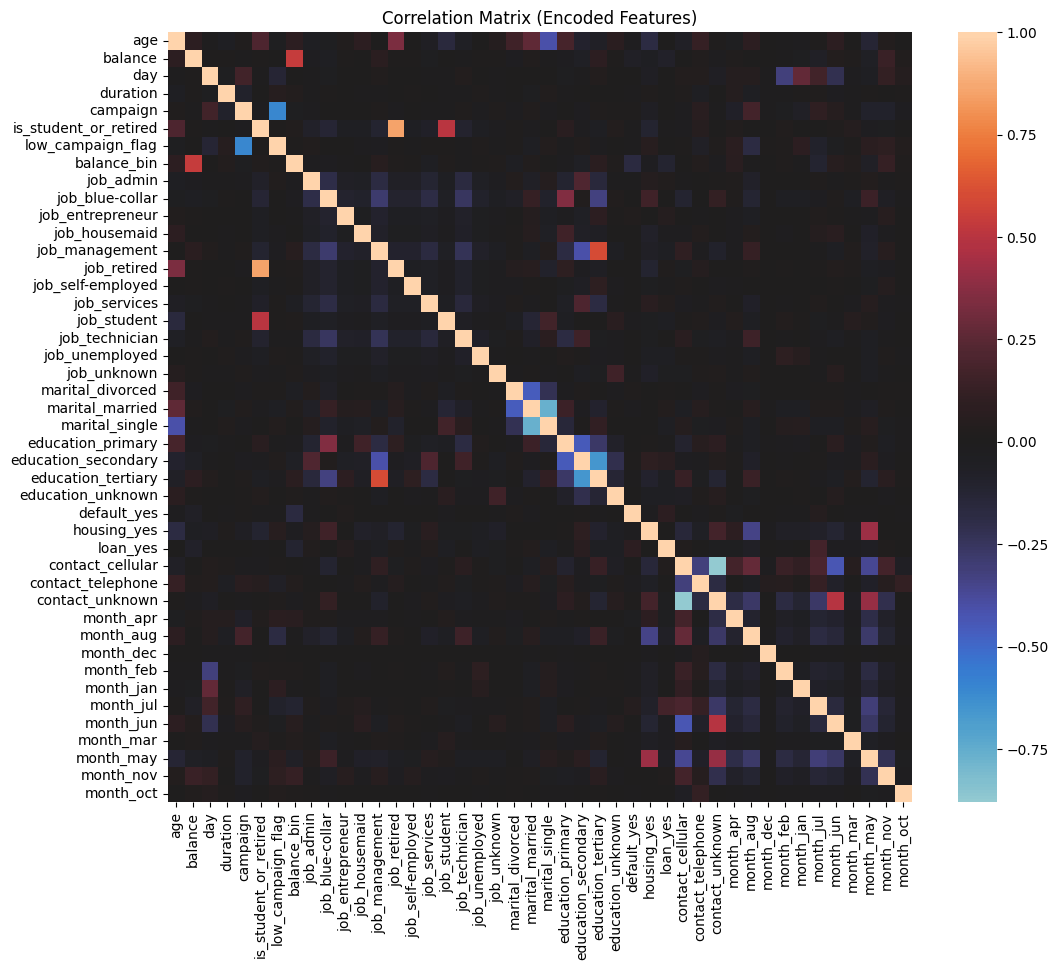

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(X_encoded.corr(), center=0)
plt.title("Correlation Matrix (Encoded Features)")
plt.show()

### Baseline Logistic Model

In [149]:
log = LogisticRegression(max_iter=20000, class_weight="balanced",)
log.fit(X_encoded, y)

coef_df = pd.Series(log.coef_[0], index=X_encoded.columns)
coef_df.sort_values(ascending=False).head(15)

month_oct                4.244063
month_mar                2.592416
month_jun                0.602629
default_yes              0.474106
contact_cellular         0.345881
contact_telephone        0.316574
is_student_or_retired    0.296477
month_feb                0.290262
month_apr                0.286344
month_dec                0.267413
job_student              0.176440
job_admin                0.153709
job_retired              0.120037
balance_bin              0.109889
job_technician           0.075507
dtype: float64

**Observations**:
* Higher education → higher likelihood
* Single/divorced → higher likelihood
* Customers with housing loans are much less likely to subscribe.
* Customers with personal loans less likely.
* More campaign attempts reduce probability.
* Customers in default less likely.

**Meaning**:
* Financial burden ↓ subscription probability
* Education ↑ subscription probability
* Low campaign count ↑ subscription probability

#### 5-Fold Stratified CV

In [150]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score),
}

cv_results = cross_validate(
    log,
    X_encoded,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

train_results = {
    metric: np.mean(cv_results[f"train_{metric}"])
    for metric in scoring.keys()
}

test_results = {
    metric: np.mean(cv_results[f"test_{metric}"])
    for metric in scoring.keys()
}
print(train_results)
print(test_results)

{'accuracy': np.float64(0.86870625), 'precision': np.float64(0.34035798296185876), 'recall': np.float64(0.8671441765191276), 'f1': np.float64(0.4888425352313429)}
{'accuracy': np.float64(0.8678000000000001), 'precision': np.float64(0.3380239808143312), 'recall': np.float64(0.8611851587159787), 'f1': np.float64(0.4854584167011515)}


### Results 5-Folds Cross Validation (Mean) on balanced set (class_weight="balanced")

|                     Model                      | Category |      Accuracy      |      Precision      |       Recall       |      F1 Score       |
|------------------------------------------------|----------|--------------------|---------------------|--------------------|---------------------|
|                 Base Logistic                  |   Train  | 0.8687374999999999 | 0.34041617054351103 | 0.8671440647075792 | 0.4889024292238786  |
|                 Base Logistic                  |   Test   | 0.8673500000000001 | 0.33724043750869076 | 0.8615305818593294 | 0.4847078778945593  |
| Base Logistic - with low corr fields removed   |   Train  | 0.8688499999999999 | 0.3406134866343856  | 0.867057783462774  | 0.4890922724361159  |
| Base Logistic - with low corr fields removed   |   Test   |       0.8675       | 0.3375972180144456  | 0.8622214281460305 | 0.48518729112410985 |
| Base Logistic - removed low corr and unkown    |   Train  |       0.866775     | 0.33566367030960065 | 0.8579939293783353 | 0.4825460231644002  |
| Base Logistic - removed low corr and unkown    |   Test   | 0.8661999999999999 | 0.33407926436956237 | 0.8532475731046393 | 0.4801237489507078  |
|   Logistic Regression - no Job Field           |   Train  |     0.86644375     | 0.33520882881048053 | 0.8591159209954509 | 0.4822518553992553  |
|   Logistic Regression - no Job Field           |   Test   | 0.8658499999999998 | 0.33374770049724745 | 0.8553183252933121 | 0.48010142161458075 |
|   Logistic Regression - no Month Field         |   Train  | 0.8469562499999999 | 0.2916425041495466  | 0.7795238393402224 | 0.42447503975718426 |
|   Logistic Regression - no Month Field         |   Test   |      0.846425      | 0.2906288701443401  | 0.7776261092251803 | 0.4231009459500341  |
|   Logistic Regression - no Contact Field       |   Train  |      0.86183125    | 0.32564770338371474 | 0.8483251748173558 | 0.47063212400758153 |
|   Logistic Regression - no Contact Field       |   Test   |      0.861575      | 0.3245437635181009  | 0.8432320886189031 | 0.46868059276776136 |
|   Logistic Regression - no Duration Field      |   Train  |      0.6691        | 0.12460279942647523 | 0.5924554412344591 | 0.20589609633170172 |
|   Logistic Regression - no Duration Field      |   Test   |      0.66835       | 0.12371789393449213 | 0.5887374188553391 | 0.20446578856220504 |
| Logistic Regression - no Job, Month or Contact |   Train  | 0.8458062500000001 | 0.2872138532429479  | 0.7624310215923008 | 0.41724625200845333 |
| Logistic Regression - no Job, Month or Contact |   Test   |       0.8458       | 0.28712090288472    | 0.7617420046453457 | 0.41704089427565566 |
| Logistic Regression - no Duration Job, Month or Contact |   Train  | 0.576 | 0.09822889453383093  | 0.593577544663123 | 0.1685601522019573 |
| Logistic Regression - no Duration Job, Month or Contact |   Test   |       0.574125     | 0.09688412427858555 | 0.5870055386814365 |  0.1663138911623912 |
| Logistic Regression - feature engineered fields + no Duration Job, Month or Contact|   Train  | 0.59940625 | 0.10011678028378039  | 0.5674207237486983 | 0.17020182732272057 |
| Logistic Regression - feature engineered fileds + no Duration Job, Month or Contact |   Test   | 0.5986499999999999     | 0.09959111931611303 | 0.56525698290751 |  0.1693430214161179 |
| Logistic Regression - feature engg + No Duration |   Train  | 0.6674562500000001 | 0.12633259539024627  | 0.6073893270659234 | 0.20916053069978124 |
| Logistic Regression - feature engg + No Duration |   Test   | 0.666175     | 0.12467240905002801 | 0.599789768328271 |  0.20643350631613258 |
| Logistic Regression - feature engg  |   Train  | 0.86870625 | 0.34035798296185876  | 0.8671441765191276 | 0.4888425352313429 |
| Logistic Regression - feature engg  |   Test   | 0.8678000000000001     | 0.3380239808143312 | 0.8611851587159787 |  0.4854584167011515 |

#### Duration Is Dominant
|           Event           | Accuracy | Recall | F1 Score |
|---------------------------|----------|--------|----------|
| When duration is included | ≈ 0.867  | ≈ 0.86 | ≈ 0.48   |
| When duration is removed  | ≈ 0.668  | 0.59   | 0.20     |

* **Conclusion**: Duration is the single strongest predictor.
* **But,** Duration is post-call information. It cannot be used for targeting before calling.
* **So:** Including duration makes the model unrealistic for campaign optimization.

#### Month Is Very Important
|           Event           | Accuracy | Recall | F1 Score |
|---------------------------|----------|--------|----------|
| When month is included    | ≈ 0.867  | ≈ 0.86 | ≈ 0.48   |
| When month is removed     | ≈ 0.86   | 0.77   | 0.42     |

* Month carries strong signal.
* But month may reflect: Campaign strategy, Macroeconomic timing, Small sample artifacts (Oct/Mar).
* So month is useful but needs careful interpretation.

#### Job & Contact Have Moderate Effect

* Removing job or contact: Small performance drop.
* So they matter, but less than month.

#### Removing Low Correlation Features

* This Didn't Change Much.
* It means your feature space is stable.
* No obvious noise dominating.

#### Probability Ranking Evaluation

In [151]:
log.fit(X_encoded, y)
probs = log.predict_proba(X_encoded)[:, 1]

df_eval = df.copy()
df_eval["pred_prob"] = probs

In [152]:
# Create Deciles
df_eval["decile"] = pd.qcut(df_eval["pred_prob"], 10, labels=False)
lift_table = df_eval.groupby("decile")["y"].apply(lambda x: (x=="yes").mean()).sort_index(ascending=False)
lift_table

decile
9    0.46725
8    0.17675
7    0.05050
6    0.01850
5    0.00300
4    0.00300
3    0.00075
2    0.00125
1    0.00100
0    0.00200
Name: y, dtype: float64

|           decile                  | 9       | 8       | 7       | 6       | 5       | 4       | 3       | 2       | 1       | 0       |
|-----------------------------------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|
| no Duration Job, Month or Contact | 0.13325 | 0.10175 | 0.09775 | 0.07050 | 0.06825 | 0.05950 | 0.05600 | 0.05075 | 0.05050 | 0.03575 |
| feature engg + No Duration        | 0.22875 | 0.10400 | 0.07575 | 0.06050 | 0.05750 | 0.05575 | 0.04275 | 0.04225 | 0.03500 | 0.02175 |
| feature engg                      | 0.46725 | 0.17675 | 0.05050 | 0.01850 | 0.00300 | 0.00300 | 0.00075 | 0.00125 | 0.00100 | 0.00200 |

### Gains Chart

In [153]:
import numpy as np
import pandas as pd

# Sort by predicted probability descending
df_sorted = df_eval.sort_values("pred_prob", ascending=False).reset_index(drop=True)

# Create cumulative percentage of population
df_sorted["cum_population_pct"] = np.arange(1, len(df_sorted)+1) / len(df_sorted)

# Create cumulative buyers captured
df_sorted["cum_positives"] = (df_sorted["y"] == "yes").cumsum()

total_positives = (df_sorted["y"] == "yes").sum()

df_sorted["cum_positive_pct"] = df_sorted["cum_positives"] / total_positives

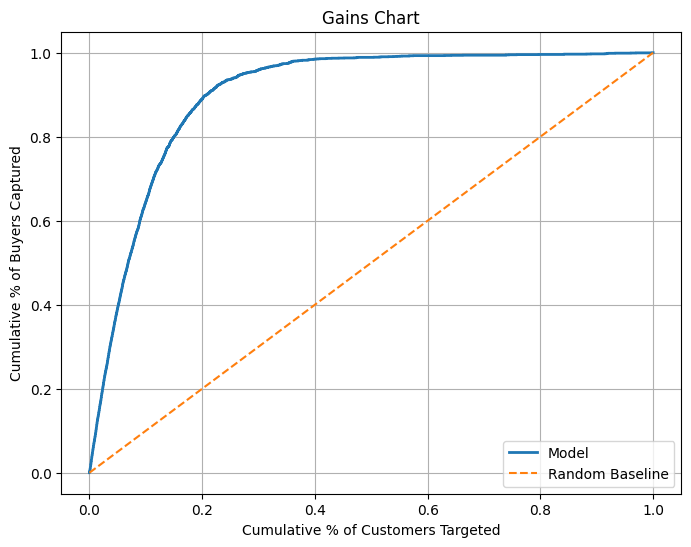

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Model gains curve
plt.plot(
    df_sorted["cum_population_pct"],
    df_sorted["cum_positive_pct"],
    label="Model",
    linewidth=2
)

# Random baseline (diagonal)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Baseline"
)

plt.xlabel("Cumulative % of Customers Targeted")
plt.ylabel("Cumulative % of Buyers Captured")
plt.title("Gains Chart")
plt.legend()
plt.grid(True)
plt.show()


In [155]:
for pct in [0.1, 0.2, 0.3, 0.5]:
    subset = df_sorted[df_sorted["cum_population_pct"] <= pct]
    captured = subset["y"].eq("yes").sum() / total_positives
    print(f"Top {int(pct*100)}% captures {captured:.2%} of buyers")

Top 10% captures 64.54% of buyers
Top 20% captures 88.95% of buyers
Top 30% captures 95.93% of buyers
Top 50% captures 98.90% of buyers


### Calls top 10% → captures 31.6% of all buyers.
* That’s over 3x better than random.
* Lift at 10% = 31.6 / 10 = 3.16x